# Comment la friction de surface est-elle communiquée à toute la troposphère&nbsp;?
## Transmission **dynamique** : régression grande-échelle, non-localité, propagation et causalité

*Notebook 9 — suite scientifique de la synthèse. Pipeline `large300` (RCEMIP Méso-NH).*

---

### Fil directeur

Les notebooks précédents ont **diagnostiqué** le flux de Reynolds $\rho_0\overline{u'w'}$ à l'équilibre :
sa forme, sa décomposition $T_1$ (organisé) $+\,T_2$ (sous-maille), son origine (tourbillons penchés).
Mais un diagnostic stationnaire montre le transport **établi**, pas la manière dont il **se propage**
depuis la surface. Ce notebook attaque le *comment dynamique* en 4 temps :

| § | Question | Approche |
|---|----------|----------|
| **1** | Une **fermeture grande-échelle** (les termes dominants de la régression) reconstruit-elle le flux&nbsp;? | Régression sur $\{\partial_z\bar u,\ z\partial_z\bar u,\ zH_z\partial_z\bar u,\ \rho_0\partial_z\bar u,\ \partial_{zz}\bar u\}$ + validation croisée temporelle |
| **2** | Le transport en $z$ dépend-il du cisaillement **ailleurs** dans la colonne&nbsp;? | Diffusivité effective $K(z)$ **non locale** : noyau $K(z,z')$ + longueur de communication |
| **3** | Combien de temps met la QdM à monter/descendre la colonne&nbsp;? | Corrélations retardées surface$\to z$ : vitesse de transit, canal turbulent vs ondulatoire |
| **4** | Peut-on établir la **chaîne causale** et pas juste la corrélation&nbsp;? | Réponse impulsionnelle (fonction de Green empirique) + causalité de Granger verticale |

> **Rappel de la question d'intro.** La viscosité de l'air étant négligeable, c'est la turbulence
> convective qui communique la friction de surface à toute la troposphère. On cherche *par quel
> mécanisme, à quelle vitesse et sur quelle distance verticale* cette communication opère — et si
> elle se laisse résumer par une fermeture simple exploitable en paramétrisation.


## §0 — Setup commun (identique au pipeline `large300`)

On réutilise strictement les mêmes conventions que les notebooks précédents : `path3d`, `idx_stat`,
`dim_*`, lecture niveau par niveau, `rho0(z)`, masques `mh/ms` (PRW), champs `flux_zt`, `ubar_zt`,
`wbar_zt`. **Exécute d'abord tes cellules setup habituelles** (celles qui produisent `rho0`, `alt`,
`flux_zt`, `ubar_zt`, `wbar_zt`, `mh`, `ms`, `dt_phys`, `n_stat`, `dim_*`).

La cellule ci-dessous ne fait que **vérifier** que ces objets existent et prépare quelques
raccourcis. Si un objet manque, relance le setup du notebook 8.

In [2]:
 #============================================================
#  SETUP COMMUN — pipeline large300 (RCEMIP Meso-NH)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import xarray as xr
import gc, os
from scipy.signal import detrend, hilbert
from scipy.ndimage import uniform_filter1d

plt.rcParams.update({'figure.dpi':120,'font.size':11,'axes.grid':True,
                     'grid.alpha':0.25,'image.cmap':'RdBu_r'})
Rd,Rv=287.05,461.5; EPSILON=Rd/Rv; g=9.81; KARMAN=0.4
Z_TOP_KM=15.0
DIR_3D,DIR_2D,DIR_1D='3D','2D','1D'
def path3d(v): return os.path.join(DIR_3D,f'MESONH_RCE_large300_3D_{v}.nc')
def path2d(v): return os.path.join(DIR_2D,f'MESONH_RCE_large300_2D_{v}.nc')
def path1d(v): return os.path.join(DIR_1D,f'MESONH_RCE_large300_1D_{v}.nc')
BLOC=2

_ds=xr.open_dataset(path3d('ua')); _da=_ds['ua']
dim_t,dim_z,dim_y,dim_x=_da.dims[:4]
n_t,n_z=_da.sizes[dim_t],_da.sizes[dim_z]; n_y,n_x=_da.sizes[dim_y],_da.sizes[dim_x]
_xv=_da[dim_x].values; dx=float(np.mean(np.diff(_xv))) if _xv.size>1 else 1000.0
if abs(dx)<=1.5: dx=1000.0
_ds.close(); del _ds,_da; gc.collect()
_ds1=xr.open_dataset(path1d('ua_avg')); alt=_ds1.altitude.values.astype(float).copy(); _ds1.close()
x=np.arange(n_x,dtype=float)*dx; zkm=alt/1000.0
mask_show=alt<=Z_TOP_KM*1000; m28=(alt>=2000)&(alt<=8000)

# fenetre stationnaire = toute la fenetre (RCE quasi-stationnaire, cf. runs precedents)
t_stat=0; idx_stat=slice(t_stat,None); n_stat=n_t-t_stat
dt_phys=6*3600.0                      # RCEMIP : snapshots 3D 6-horaires

# masques humide/sec (PRW)
ds_prw=xr.open_dataset(path2d('prw')); prw_all=ds_prw['prw'].load(); ds_prw.close()
prw_mean=prw_all.isel({dim_t:idx_stat}).mean(dim=dim_t)
PRW_SEUIL=float(np.median(prw_all.values.ravel()))
mh=(prw_mean.values>PRW_SEUIL); ms=~mh; del prw_all; gc.collect()

print(f'{n_t} t x {n_z} z x {n_y} y x {n_x} x | dx={dx:.0f}m | dt={dt_phys/3600:.0f}h')
print(f'altitude {alt[0]:.0f}-{alt[-1]:.0f}m | z[1]={alt[1]:.0f}m | fenetre {n_stat} pas = {n_stat*dt_phys/86400:.0f} j')
print(f'humide {mh.mean()*100:.0f}% / sec {ms.mean()*100:.0f}% (seuil PRW={PRW_SEUIL:.1f})')


100 t x 74 z x 128 y x 2000 x | dx=1000m | dt=6h
altitude 0-32500m | z[1]=37m | fenetre 100 pas = 25 j
humide 43% / sec 57% (seuil PRW=30.4)


In [3]:
 #============================================================
#  CHAMPS DE BASE : rho0(z), profils ET champs (z,t)
#   - profils moyens : flux_tot, ubar, dudz, uw       (1D, pour §1-§5-§6)
#   - champs (z,t)   : flux_zt, ubar_zt, wbar_zt, ...  (2D, pour le contexte)
# ============================================================
# rho0(z)
rho0_sum=np.zeros(n_z); n_rho=0
ds_ta=xr.open_dataset(path3d('ta')); ds_pa=xr.open_dataset(path3d('pa')); ds_hus=xr.open_dataset(path3d('hus'))
for t0 in range(t_stat,n_t,BLOC):
    t1=min(t0+BLOC,n_t); sl={dim_t:slice(t0,t1)}
    T=ds_ta['ta'].isel(sl).values; p=ds_pa['pa'].isel(sl).values; qv=ds_hus['hus'].isel(sl).values
    Tv=T*(1+qv/EPSILON)/(1+qv); rho=p/(Rd*Tv)
    rho0_sum+=rho.mean(axis=(0,2,3))*(t1-t0); n_rho+=(t1-t0)
    del T,p,qv,Tv,rho; gc.collect()
ds_ta.close(); ds_pa.close(); ds_hus.close(); rho0=rho0_sum/n_rho

# champs (z,t) : flux, ubar, wbar   (niveau par niveau)
flux_zt=np.zeros((n_z,n_stat)); ubar_zt=np.zeros((n_z,n_stat)); wbar_zt=np.zeros((n_z,n_stat))
ds_u=xr.open_dataset(path3d('ua')); ds_w=xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    u=ds_u['ua'].isel({dim_t:idx_stat,dim_z:iz}).values
    w=ds_w['wa'].isel({dim_t:idx_stat,dim_z:iz}).values
    ub=u.mean(axis=(1,2)); wb=w.mean(axis=(1,2))
    up=u-ub[:,None,None]; wp=w-wb[:,None,None]
    flux_zt[iz]=rho0[iz]*(up*wp).mean(axis=(1,2)); ubar_zt[iz]=ub; wbar_zt[iz]=wb
    del u,w,up,wp; gc.collect()
ds_u.close(); ds_w.close(); gc.collect()

# profils moyens (moyenne temporelle des champs zt)
flux_tot=flux_zt.mean(1); ubar=ubar_zt.mean(1); wbar=wbar_zt.mean(1)
uw=flux_tot/rho0; dudz=np.gradient(ubar,alt); d2udz2=np.gradient(dudz,alt)
# derivees des champs zt (pour le contexte dynamique)
dudz_zt=np.gradient(ubar_zt,alt,axis=0); d2udz2_zt=np.gradient(dudz_zt,alt,axis=0)
uw_zt=flux_zt/rho0[:,None]
print(f'rho0 surface={rho0[0]:.3f} | ~10km={rho0[np.argmin(np.abs(alt-10000))]:.3f} kg/m3')
print('profils (flux_tot,ubar,dudz,uw) et champs (flux_zt,ubar_zt,...) prets.')


rho0 surface=1.183 | ~10km=0.410 kg/m3
profils (flux_tot,ubar,dudz,uw) et champs (flux_zt,ubar_zt,...) prets.


In [4]:
# --- Vérification des objets hérités du pipeline (setup notebook 8) ---
import numpy as np, matplotlib.pyplot as plt, gc
from numpy.linalg import lstsq

_required = ['rho0','alt','flux_zt','ubar_zt','wbar_zt','mh','ms',
             'dt_phys','n_stat','n_z','dim_t','dim_z','idx_stat']
_g = globals()
_missing = [k for k in _required if k not in _g]
assert not _missing, f"Objets manquants -> relance le setup large300 : {_missing}"

zkm   = alt/1000.0
Z_LO, Z_HI = 2000.0, 18000.0                 # fenêtre d'étude (2-18 km, comme la régression synthèse)
band  = (alt>=Z_LO)&(alt<=Z_HI)
iz_band = np.where(band)[0]

# profils moyens temporels (au cas où non définis)
flux_tot = flux_zt.mean(1)
ubar     = ubar_zt.mean(1)
dudz     = np.gradient(ubar, alt)
d2udz2   = np.gradient(dudz, alt)
uw       = flux_tot/rho0

print(f"OK. {n_z} niveaux, fenêtre 2-18 km = {band.sum()} niveaux, {n_stat} pas de temps.")
print(f"flux_tot min={flux_tot.min():.2e} @ {alt[np.argmin(flux_tot)]:.0f} m")


OK. 74 niveaux, fenêtre 2-18 km = 33 niveaux, 100 pas de temps.
flux_tot min=-1.17e-02 @ 4500 m


fraction humide fh=0.43 / sèche fs=0.57
contrôle identité |(org+int) - global|_max = 2.01e-08  (doit être ~0)
part médiane du CONTRASTE inter-régions dans |flux| (2-18 km) : 1%
=> le reste (~99%) est de la turbulence INTERNE aux régions.


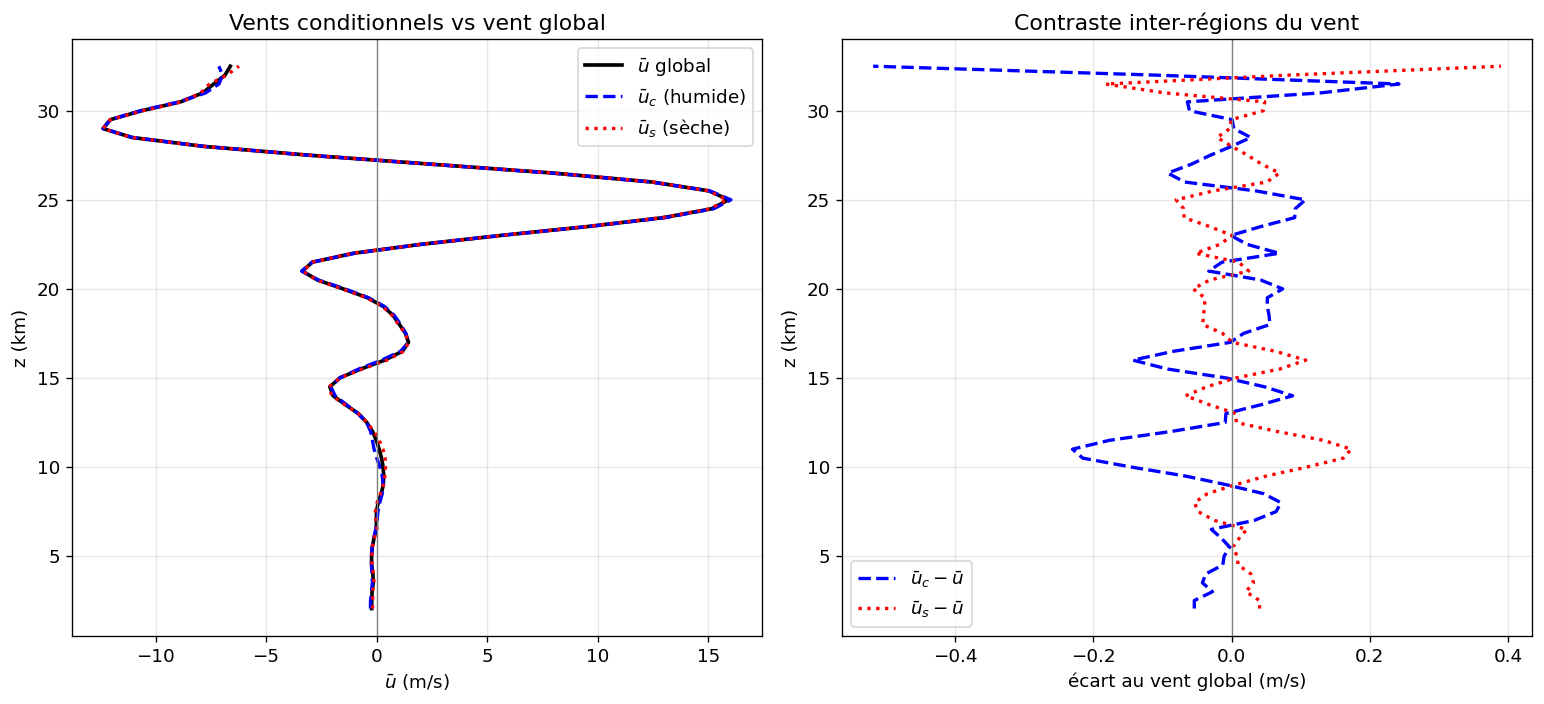

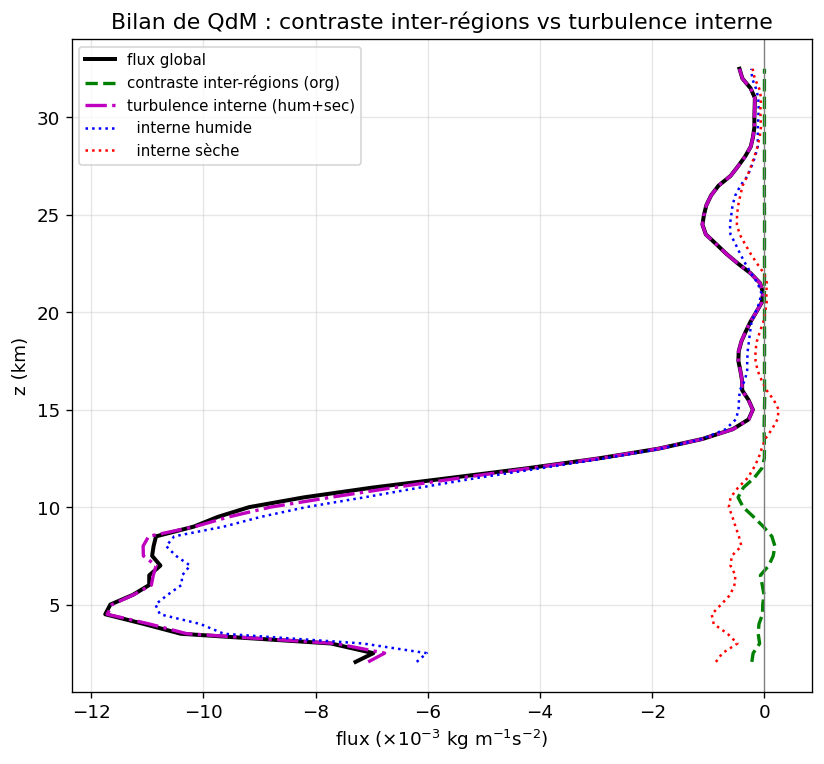


Lecture :
 - Si u_c et u_s collent à <u> => contraste faible => transport surtout INTERNE aux régions.
 - Si u_c et u_s divergent     => le transport a une vraie composante GRANDE ÉCHELLE
   (circulation humide/sèche organisée) qu'une paramétrisation de domaine ignore.


In [15]:
# ============================================================
#  §0bis — DÉCOMPOSITION DU BILAN DE QdM PAR RÉGION (humide Ac / sèche As)
#  Idée (photo) : partir de   rho0 dt<u> + (1/A) ∮ ∇·(rho0 u u) ≈ 0   (z >~ 2 km)
#  et scinder l'intégrale de domaine en deux sous-domaines :
#
#     rho0 dt<u> + (1/A)[ ∫_Ac ∇·(rho0 u u) + ∫_As ∇·(rho0 u u) ] ≈ 0
#
#  Dans CHAQUE région, on décompose le vent par rapport à SA PROPRE moyenne
#  conditionnelle (et non la moyenne globale) :
#       région humide :  u = u_c + u_c'      (u_c = <u>_humide)
#       région sèche  :  u = u_s + u_s'      (u_s = <u>_seche)
#
#  Objectif : (1) plotter u_c, u_s vs u_global pour voir s'ils ressemblent
#             à <u> ou pas  -> mesure du CONTRASTE INTER-RÉGIONS ;
#             (2) isoler, dans le flux vertical de QdM, la part "grande échelle"
#             (contraste des moyennes conditionnelles) de la part "turbulence
#             interne" à chaque région.
#  Tout est calculé niveau par niveau (RAM), fenêtre stationnaire idx_stat.
# ============================================================
import numpy as np, matplotlib.pyplot as plt, gc, xarray as xr

fh = mh.mean()          # fraction d'aire humide
fs = ms.mean()          # fraction d'aire sèche
zkm = alt/1000.0
band2 = alt >= 2000.0   # domaine de validité du bilan (photo : z >~ 2 km)

# --- profils conditionnels : u_c(z), u_s(z), et flux décomposé -----------
u_glob  = np.zeros(n_z)                       # <u> global (rappel)
u_c     = np.zeros(n_z)                       # <u>_humide
u_s     = np.zeros(n_z)                       # <u>_seche
w_c     = np.zeros(n_z); w_s = np.zeros(n_z)  # <w> conditionnels

flux_glob = np.zeros(n_z)                     # rho0 <u'w'>          (réf)
flux_org  = np.zeros(n_z)                     # part CONTRASTE inter-régions (grande échelle)
flux_int  = np.zeros(n_z)                     # part TURBULENCE interne (humide+sèche)
flux_ch   = np.zeros(n_z); flux_cs = np.zeros(n_z)  # interne humide / interne sèche

ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    u = ds_u['ua'].isel({dim_t: idx_stat, dim_z: iz}).values   # (n_stat, ny, nx)
    w = ds_w['wa'].isel({dim_t: idx_stat, dim_z: iz}).values

    # moyennes globales (sur tout le domaine + temps)
    ub = u.mean(); wb = w.mean()
    u_glob[iz] = ub

    # moyennes CONDITIONNELLES (masques 2D appliqués sur chaque snapshot)
    uc = u[:, mh].mean(); wc = w[:, mh].mean()   # humide
    us = u[:, ms].mean(); ws = w[:, ms].mean()   # sèche
    u_c[iz], w_c[iz] = uc, wc
    u_s[iz], w_s[iz] = us, ws

    # --- flux global (réf) : anomalies vs moyenne GLOBALE ---
    up = u - ub; wp = w - wb
    flux_glob[iz] = rho0[iz] * (up*wp).mean()

    # --- décomposition "loi de la variance totale" ---
    # flux_glob = [ fh*(uc-ub)(wc-wb) + fs*(us-ub)(ws-wb) ]        <- CONTRASTE (org)
    #           + [ fh*<u'w'>_hum      + fs*<u'w'>_sec     ]        <- INTERNE
    org = fh*(uc-ub)*(wc-wb) + fs*(us-ub)*(ws-wb)
    uph = u[:, mh] - uc; wph = w[:, mh] - wc     # fluct. internes humides
    ups = u[:, ms] - us; wps = w[:, ms] - ws     # fluct. internes sèches
    ch  = (uph*wph).mean();  cs = (ups*wps).mean()
    flux_ch[iz] = rho0[iz]*fh*ch
    flux_cs[iz] = rho0[iz]*fs*cs
    flux_org[iz] = rho0[iz]*org
    flux_int[iz] = flux_ch[iz] + flux_cs[iz]

    del u, w, up, wp, uph, wph, ups, wps; gc.collect()
ds_u.close(); ds_w.close(); gc.collect()

# --- contrôle d'identité : org + int == flux global ? -------------------
resid = np.abs((flux_org+flux_int) - flux_glob).max()
print(f"fraction humide fh={fh:.2f} / sèche fs={fs:.2f}")
print(f"contrôle identité |(org+int) - global|_max = {resid:.2e}  (doit être ~0)")

# part relative du contraste inter-régions dans le flux (médiane 2-18 km)
b = band2 & (alt<=18000)
share_org = np.nanmedian(np.abs(flux_org[b])/(np.abs(flux_glob[b])+1e-30))*100
print(f"part médiane du CONTRASTE inter-régions dans |flux| (2-18 km) : {share_org:.0f}%")
print(f"=> le reste (~{100-share_org:.0f}%) est de la turbulence INTERNE aux régions.")

# ============================================================
#  FIGURE 1 : u_c, u_s ressemblent-ils à <u> ?  (la question de la photo)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

ax = axes[0]
ax.plot(u_glob[band2], zkm[band2], 'k-',  lw=2.2, label=r'$\bar u$ global')
ax.plot(u_c[band2],    zkm[band2], 'b--', lw=2,   label=r'$\bar u_c$ (humide)')
ax.plot(u_s[band2],    zkm[band2], 'r:',  lw=2,   label=r'$\bar u_s$ (sèche)')
ax.axvline(0, color='grey', lw=.8)
ax.set_xlabel(r'$\bar u$ (m/s)'); ax.set_ylabel('z (km)')
ax.set_title('Vents conditionnels vs vent global')
ax.legend(); ax.grid(alpha=.3)

# écart des vents conditionnels au vent global (le "contraste")
ax = axes[1]
ax.plot((u_c-u_glob)[band2], zkm[band2], 'b--', lw=2, label=r'$\bar u_c-\bar u$')
ax.plot((u_s-u_glob)[band2], zkm[band2], 'r:',  lw=2, label=r'$\bar u_s-\bar u$')
ax.axvline(0, color='grey', lw=.8)
ax.set_xlabel(r'écart au vent global (m/s)'); ax.set_ylabel('z (km)')
ax.set_title('Contraste inter-régions du vent')
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

# ============================================================
#  FIGURE 2 : décomposition du flux  global = contraste + interne
# ============================================================
fig, ax = plt.subplots(figsize=(7, 6.5))
ax.plot(flux_glob[band2]*1e3, zkm[band2], 'k-',  lw=2.4, label='flux global')
ax.plot(flux_org[band2] *1e3, zkm[band2], 'g--', lw=2,   label='contraste inter-régions (org)')
ax.plot(flux_int[band2] *1e3, zkm[band2], 'm-.', lw=2,   label='turbulence interne (hum+sec)')
ax.plot(flux_ch[band2]  *1e3, zkm[band2], 'b:',  lw=1.5, label='  interne humide')
ax.plot(flux_cs[band2]  *1e3, zkm[band2], 'r:',  lw=1.5, label='  interne sèche')
ax.axvline(0, color='grey', lw=.8)
ax.set_xlabel(r"flux ($\times10^{-3}$ kg m$^{-1}$s$^{-2}$)"); ax.set_ylabel('z (km)')
ax.set_title('Bilan de QdM : contraste inter-régions vs turbulence interne')
ax.legend(fontsize=9); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

print("\nLecture :")
print(" - Si u_c et u_s collent à <u> => contraste faible => transport surtout INTERNE aux régions.")
print(" - Si u_c et u_s divergent     => le transport a une vraie composante GRANDE ÉCHELLE")
print("   (circulation humide/sèche organisée) qu'une paramétrisation de domaine ignore.")

---
# §1 — Une fermeture grande-échelle reconstruit-elle le flux&nbsp;?

**Point de départ demandé.** La régression de la synthèse (Figure « Poids de chaque terme, 2–18 km »)
faisait ressortir, par ordre d'importance, des termes **tous bâtis sur le cisaillement** $\partial_z\bar u$ :

$$\partial_z\bar u\ (37.6\%),\quad zH_z\,\partial_z\bar u\ (17.6\%),\quad z\,\partial_z\bar u\ (9.8\%),\quad
\text{intercept}\ (7.6\%),\quad \rho_0\,\partial_z\bar u\ (6.9\%),\quad \partial_{zz}\bar u\ (4.1\%)\ \dots$$

La lecture physique est forte : **le prédicteur dominant du flux est le cisaillement du vent moyen**,
modulé par l'altitude ($z$, $zH_z$) et la densité ($\rho_0$). C'est la signature d'une fermeture de
type **viscosité turbulente** $\rho_0\overline{u'w'} \approx -K(z)\,\partial_z\bar u$, mais avec un
$K(z)$ qui **change de signe** (transport contre-gradient) — sinon le terme ne dominerait pas une
régression sur un flux en partie contre-gradient.

On teste ça proprement, avec **validation croisée temporelle** (on entraîne sur les premiers pas de
temps, on teste sur les derniers) pour distinguer une vraie loi d'un sur-apprentissage.

In [5]:
# ============================================================
#  §1.1  Dictionnaire grande-échelle (termes de la synthèse)
#  Cible : profil de flux rho0<u'w'>(z), fenêtre 2-18 km.
#  Prédicteurs : construits UNIQUEMENT sur le vent moyen résolu
#                (ce qu'un GCM connaît) -> fermeture exploitable.
# ============================================================
z   = alt.copy()
Hz  = np.gradient(np.log(rho0), z)          # -1/H (échelle de densité), = dln(rho0)/dz

def build_library(ubar_profile):
    # construit le dictionnaire de termes grande-echelle a partir d un profil de vent moyen
    du   = np.gradient(ubar_profile, z)
    d2u  = np.gradient(du, z)
    lib = {
        'dudz'        : du,
        'z_dudz'      : z*du,
        'zHz_dudz'    : z*Hz*du,
        'rho0_dudz'   : rho0*du,
        'd2udz2'      : d2u,
        'z_d2udz2'    : z*d2u,
        'rho0_d2udz2' : rho0*d2u,
        'drho0dz_dudz': np.gradient(rho0,z)*du,
        'intercept'   : np.ones_like(z),
    }
    return lib

names = ['dudz','zHz_dudz','z_dudz','intercept','rho0_dudz','d2udz2',
         'drho0dz_dudz','z_d2udz2','rho0_d2udz2']

lib_mean = build_library(ubar)
X = np.column_stack([lib_mean[n][iz_band] for n in names])
y = flux_tot[iz_band]

# normalisation colonne (pour comparer les poids)
Xm, Xs = X.mean(0), X.std(0)
Xs = np.where(Xs<1e-30, 1.0, Xs)   # garde la colonne intercept
Xs_ = (X-Xm)/Xs
coef,_,_,_ = lstsq(Xs_, y, rcond=None)
yhat = Xs_@coef

def nse(obs, pred):
    return 1 - np.sum((obs-pred)**2)/np.sum((obs-obs.mean())**2)

print(f"[Régression profil moyen 2-18 km]  R² = {nse(y,yhat):+.3f}")
print("Poids standardisés (|coef|, tri décroissant) :")
for n,c in sorted(zip(names,coef), key=lambda t:-abs(t[1])):
    print(f"   {n:14s} {c:+.3e}")


[Régression profil moyen 2-18 km]  R² = -1.130
Poids standardisés (|coef|, tri décroissant) :
   z_dudz         -5.005e-01
   dudz           +3.842e-01
   zHz_dudz       -2.159e-01
   d2udz2         +1.493e-01
   z_d2udz2       -1.158e-01
   drho0dz_dudz   +5.776e-02
   rho0_dudz      -4.463e-02
   rho0_d2udz2    -3.504e-02
   intercept      -2.082e-17


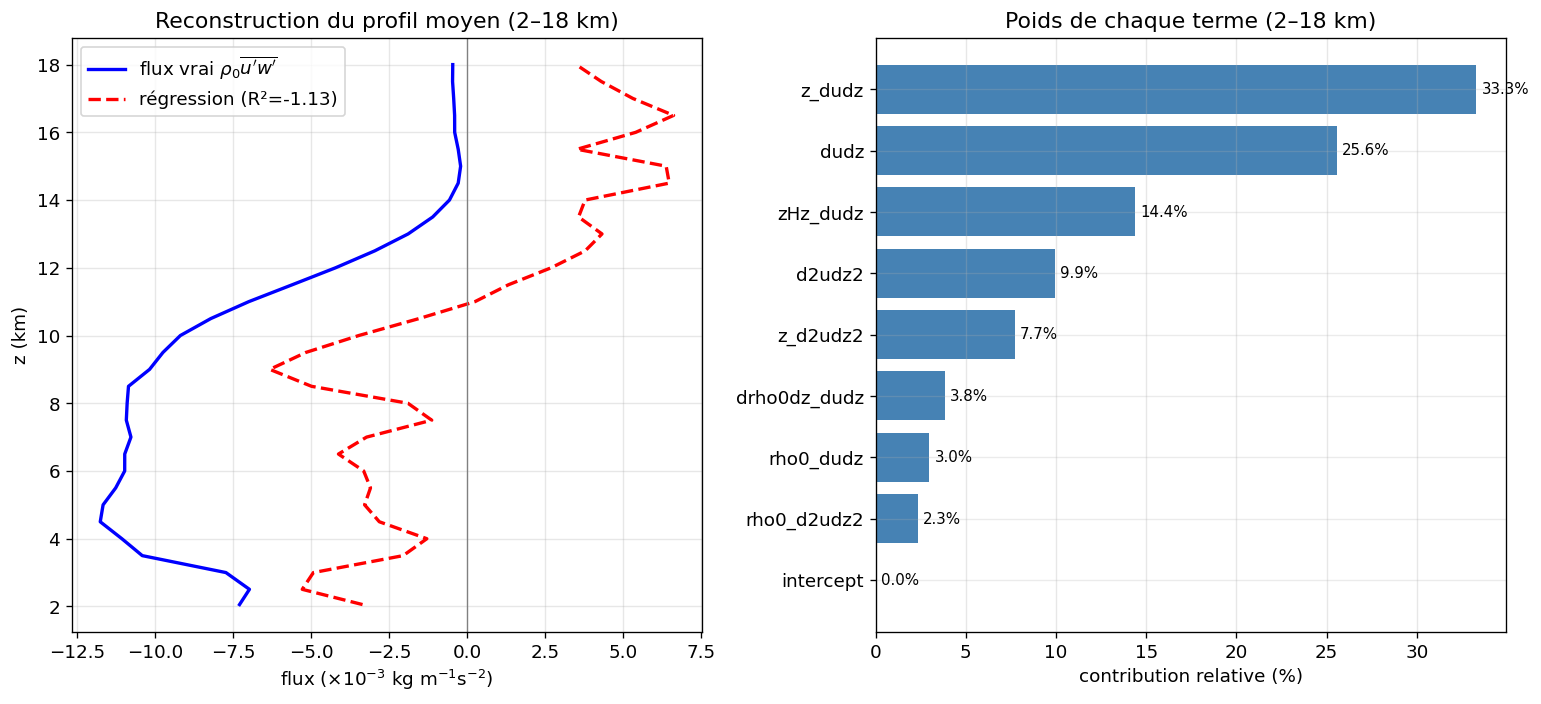

In [6]:
# ============================================================
#  §1.2  Figure : reconstruction du profil moyen + poids des termes
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13,6))

ax=axes[0]
ax.plot(y*1e3, zkm[iz_band], 'b-', lw=2, label=r"flux vrai $\rho_0\overline{u'w'}$")
ax.plot(yhat*1e3, zkm[iz_band], 'r--', lw=2, label=f"régression (R²={nse(y,yhat):.2f})")
ax.axvline(0, color='grey', lw=.8)
ax.set_xlabel(r"flux ($\times10^{-3}$ kg m$^{-1}$s$^{-2}$)"); ax.set_ylabel("z (km)")
ax.set_title("Reconstruction du profil moyen (2–18 km)"); ax.legend(); ax.grid(alpha=.3)

ax=axes[1]
order=np.argsort(np.abs(coef))
contrib = 100*np.abs(coef)/np.abs(coef).sum()
ax.barh([names[i] for i in order], contrib[order], color='steelblue')
for i,ii in enumerate(order):
    ax.text(contrib[ii]+.3, i, f"{contrib[ii]:.1f}%", va='center', fontsize=9)
ax.set_xlabel("contribution relative (%)")
ax.set_title("Poids de chaque terme (2–18 km)"); ax.grid(alpha=.3, axis='x')
plt.tight_layout(); plt.show()


### §1.3 — Validation croisée temporelle (le test qui compte)

Un $R^2$ élevé sur le profil moyen ne prouve rien : avec 9 termes et ~40 niveaux on peut sur-ajuster.
Le vrai test : **entraîner les coefficients sur une partie des pas de temps et prédire les autres**.
On calcule le flux instantané par pas de temps `flux_zt[:,t]`, on ajuste sur les premiers 70 % des
pas et on mesure le NSE sur les 30 % restants. Si la fermeture est physique, elle doit **généraliser**.

In [7]:
# ============================================================
#  §1.3  Validation croisée temporelle
#  On régresse flux_zt[:,t] sur la librairie construite à partir de ubar_zt[:,t]
#  (chaque pas de temps a son propre profil de vent -> son propre dictionnaire).
# ============================================================
def library_zt(names):
    # empile la librairie evaluee a chaque pas de temps -> (n_band, n_terms, n_stat)
    cols=[]
    for t in range(n_stat):
        lib_t = build_library(ubar_zt[:,t])
        cols.append(np.column_stack([lib_t[n][iz_band] for n in names]))
    return np.stack(cols, axis=-1)   # (n_band, n_terms, n_stat)

Lib = library_zt(names)                       # (nb, nt_terms, n_stat)
Yzt = flux_zt[iz_band,:]                       # (nb, n_stat)

t_split = int(0.70*n_stat)
def stack_time(Lib, Y, ts):
    Xs = np.concatenate([Lib[...,t] for t in ts], axis=0)   # (nb*|ts|, nterms)
    ys = np.concatenate([Y[:,t]     for t in ts], axis=0)
    return Xs, ys

Xtr,ytr = stack_time(Lib, Yzt, range(t_split))
Xte,yte = stack_time(Lib, Yzt, range(t_split,n_stat))

# standardisation sur le train uniquement
mu,sd = Xtr.mean(0), Xtr.std(0)+1e-30
b,_,_,_ = lstsq((Xtr-mu)/sd, ytr, rcond=None)
pred_te = ((Xte-mu)/sd)@b
pred_tr = ((Xtr-mu)/sd)@b

print(f"train : R²={nse(ytr,pred_tr):+.3f}  ({t_split} pas)")
print(f"test  : NSE={nse(yte,pred_te):+.3f}  ({n_stat-t_split} pas)  <-- généralisation")
print()
if nse(yte,pred_te) > 0.3:
    print(">> La fermeture grande-échelle généralise : le cisaillement (+modulations z,rho0)")
    print(">> porte une part reconstructible et STABLE du flux. Base solide pour §2.")
else:
    print(">> Généralisation limitée : la fermeture LOCALE plafonne -> motive la NON-LOCALITÉ (§2).")


train : R²=-0.928  (70 pas)
test  : NSE=-1.403  (30 pas)  <-- généralisation

>> Généralisation limitée : la fermeture LOCALE plafonne -> motive la NON-LOCALITÉ (§2).


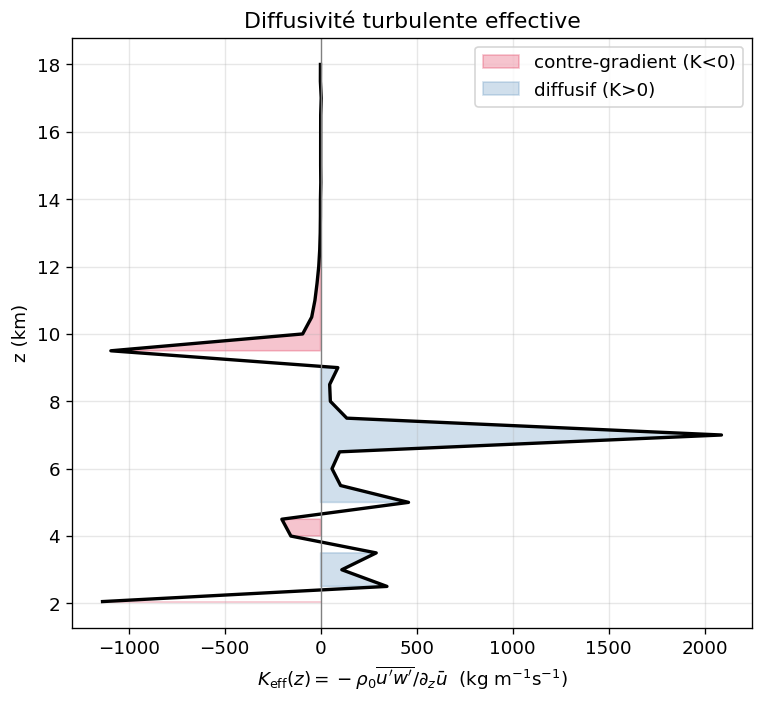

Fraction de la colonne 2-18 km en régime contre-gradient (K<0) : 45%
=> une viscosité turbulente positive standard est structurellement incapable
   de représenter ces niveaux : il faut un K(z) signé, donc NON LOCAL (§2).


In [8]:
# ============================================================
#  §1.4  Diffusivité turbulente effective K(z) et signe (contre-gradient ?)
#  Si le flux ~ -K dudz, alors K(z) = -flux / dudz. Où K<0 => contre-gradient.
# ============================================================
K_eff = -flux_tot/np.where(np.abs(dudz)<1e-6, np.nan, dudz)

fig,ax=plt.subplots(figsize=(6.5,6))
ax.plot(K_eff[band], zkm[band], 'k-', lw=2)
ax.fill_betweenx(zkm[band], 0, K_eff[band],
                 where=(K_eff[band]<0), color='crimson', alpha=.25, label='contre-gradient (K<0)')
ax.fill_betweenx(zkm[band], 0, K_eff[band],
                 where=(K_eff[band]>=0), color='steelblue', alpha=.25, label='diffusif (K>0)')
ax.axvline(0,color='grey',lw=.8)
ax.set_xlabel(r"$K_{\rm eff}(z) = -\rho_0\overline{u'w'}/\partial_z\bar u$  (kg m$^{-1}$s$^{-1}$)")
ax.set_ylabel("z (km)"); ax.set_title("Diffusivité turbulente effective")
ax.legend(); ax.grid(alpha=.3)
frac_cg = np.mean(K_eff[band]<0)*100
plt.tight_layout(); plt.show()
print(f"Fraction de la colonne 2-18 km en régime contre-gradient (K<0) : {frac_cg:.0f}%")
print("=> une viscosité turbulente positive standard est structurellement incapable")
print("   de représenter ces niveaux : il faut un K(z) signé, donc NON LOCAL (§2).")


---
# §2 — Le transport en $z$ dépend-il du cisaillement **ailleurs**&nbsp;? (non-localité)

§1 a montré que le cisaillement local domine la régression, mais qu'une fermeture **locale**
($K$ scalaire par niveau) laisse des niveaux contre-gradient qu'aucune viscosité positive ne peut
capturer. L'hypothèse physique naturelle pour un transport **convectif** est qu'il est **non local** :
un panache né en bas transporte la QdM sur toute sa hauteur. On teste donc une fermeture intégrale

$$\rho_0\overline{u'w'}(z)\;=\;\int K(z,z')\,\partial_{z'}\bar u(z')\,\mathrm{d}z' \;+\;\varepsilon(z),$$

où $K(z,z')$ est un **noyau de transport**. Si $K$ est diagonal → transport local (diffusif). Si $K$
a une **largeur** finie autour de la diagonale → distance de communication verticale. Si $K$ a des
lobes hors-diagonale → transport **non local** (le flux à $z$ est piloté par le cisaillement à $z'\neq z$).

On estime $K$ par régression **régularisée** (ridge) sur les fluctuations temporelles : à chaque pas
de temps, $\delta\text{flux}(z,t)=\sum_{z'}K(z,z')\,\delta(\partial_{z'}\bar u)(z',t)$.

In [9]:
# ============================================================
#  §2.1  Estimation du noyau non-local K(z,z') par ridge sur les
#        fluctuations TEMPORELLES (anomalies vs moyenne temporelle).
#  Modèle : flux'(z,t) = sum_z' K(z,z') * dudz'(z',t)
#           (' = anomalie temporelle ; enlève l'état moyen)
# ============================================================
from numpy.linalg import solve

# cisaillement instantané (z,t) et anomalies temporelles
dudz_zt = np.gradient(ubar_zt, alt, axis=0)                # (n_z, n_stat)
Sb  = band                                                  # restreint 2-18 km
Zc  = np.where(Sb)[0]
S   = dudz_zt[Sb,:]                                         # (nb, nt)  prédicteur
F   = flux_zt[Sb,:]                                         # (nb, nt)  cible
S  -= S.mean(1, keepdims=True)                             # anomalies temporelles
F  -= F.mean(1, keepdims=True)
nb_, nt_ = S.shape

# ridge : pour chaque z (ligne de K), résoudre  F[z,:] ~ K[z,:] @ S
#   K[z,:] = F[z,:] S^T (S S^T + lam I)^-1
lam = 1e-3 * np.trace(S@S.T)/nb_
G   = S@S.T + lam*np.eye(nb_)
Kmat = (F@S.T) @ np.linalg.inv(G)                          # (nb, nb)  noyau K(z,z')

# reconstruction & score
Frec = Kmat@S
def nse(o,p): return 1-np.sum((o-p)**2)/np.sum((o-o.mean())**2)
print(f"[Noyau non-local] NSE fluctuations = {nse(F.ravel(),Frec.ravel()):+.3f}")
print(f"K : matrice {Kmat.shape}, fenêtre {alt[Zc[0]]:.0f}-{alt[Zc[-1]]:.0f} m")


[Noyau non-local] NSE fluctuations = +0.631
K : matrice (33, 33), fenêtre 2055-18000 m


/tmp/ipykernel_18190/1336808721.py:10: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im=ax.pcolormesh(zc_km, zc_km, Kmat, cmap='RdBu_r',


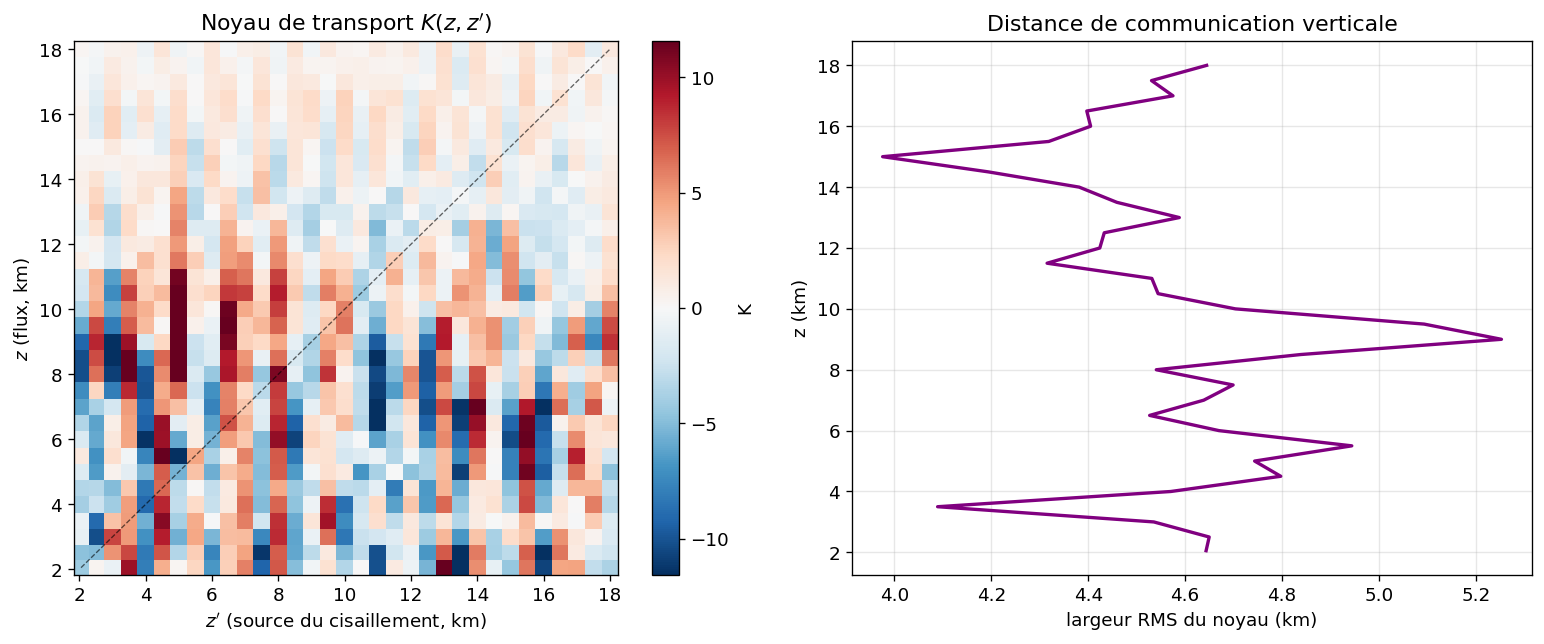

Largeur médiane du noyau : 4.5 km
=> distance typique sur laquelle le cisaillement à z' influence le flux à z.
   Largeur >> résolution => transport NON LOCAL (un schéma diffusif local est insuffisant).


In [10]:
# ============================================================
#  §2.2  Figure : le noyau K(z,z') + largeur de communication
# ============================================================
from matplotlib.colors import TwoSlopeNorm
fig, axes = plt.subplots(1, 2, figsize=(13,5.5))

ax=axes[0]
zc_km = zkm[Zc]
v = np.percentile(np.abs(Kmat), 98)
im=ax.pcolormesh(zc_km, zc_km, Kmat, cmap='RdBu_r',
                 norm=TwoSlopeNorm(0,-v,v), shading='auto')
ax.plot(zc_km, zc_km, 'k--', lw=.8, alpha=.6)
ax.set_xlabel(r"$z'$ (source du cisaillement, km)")
ax.set_ylabel(r"$z$ (flux, km)")
ax.set_title(r"Noyau de transport $K(z,z')$")
fig.colorbar(im, ax=ax, label='K')

# largeur du noyau autour de la diagonale (distance de communication)
ax=axes[1]
widths=[]
for i in range(nb_):
    row=np.abs(Kmat[i,:]); 
    if row.sum()<1e-30: widths.append(np.nan); continue
    c=np.sum(row*zc_km)/row.sum()                      # centroïde
    w=np.sqrt(np.sum(row*(zc_km-c)**2)/row.sum())      # largeur RMS (km)
    widths.append(w)
widths=np.array(widths)
ax.plot(widths, zc_km, 'purple', lw=2)
ax.set_xlabel("largeur RMS du noyau (km)")
ax.set_ylabel("z (km)")
ax.set_title("Distance de communication verticale")
ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f"Largeur médiane du noyau : {np.nanmedian(widths):.1f} km")
print("=> distance typique sur laquelle le cisaillement à z' influence le flux à z.")
print("   Largeur >> résolution => transport NON LOCAL (un schéma diffusif local est insuffisant).")


**Lecture.** Une largeur de noyau de plusieurs kilomètres, et surtout des lobes **hors-diagonale**
(en dessous de la diagonale : le flux à l'altitude $z$ est piloté par le cisaillement plus **bas**),
est la signature directe de la transmission : *la friction/le cisaillement généré en bas est
communiqué vers le haut par des structures profondes*. C'est la version « fermeture » de la réponse
à la question d'intro. On quantifie maintenant la **vitesse** de cette communication (§3).

---
# §3 — À quelle vitesse la QdM parcourt-elle la colonne&nbsp;? (propagation)

On a la structure spatiale ; il manque le **temps**. Idée : la friction module le flux en surface,
et cette information met un certain temps à atteindre l'altitude $z$. On mesure la **corrélation
retardée** entre une référence basse (flux ou cisaillement près de la surface) et le flux à chaque
niveau, en fonction du décalage $\tau$ :

$$C(z,\tau)=\mathrm{corr}\big(\,\Phi_{\rm ref}(t),\ \Phi(z,t+\tau)\,\big).$$

Le maximum de $|C|$ pour chaque $z$ donne le **retard optimal** $\tau^\star(z)$ ; la pente
$\mathrm{d}z/\mathrm{d}\tau^\star$ est une **vitesse de propagation verticale** de la QdM. On sépare
ainsi le canal turbulent (rapide) du canal ondulatoire déjà mesuré ($c_z\approx-0.6$ cm/s, QBO).

In [11]:
# ============================================================
#  §3.1  Corrélation retardée réf-basse -> flux(z)
# ============================================================
from scipy.signal import detrend

# référence : anomalie de flux au niveau de référence bas (~1 km)
iz_ref = np.argmin(np.abs(alt-1000.0))
ref = detrend(flux_zt[iz_ref,:])
ref = (ref-ref.mean())/(ref.std()+1e-30)

Fana = detrend(flux_zt[band,:], axis=1)
Fana = (Fana-Fana.mean(1,keepdims=True))/(Fana.std(1,keepdims=True)+1e-30)
zc_km = zkm[band]

lags = np.arange(-(n_stat//2), n_stat//2+1)          # en pas de temps
C = np.zeros((band.sum(), lags.size))
for j,L in enumerate(lags):
    if L>=0:
        a=ref[:n_stat-L]; b=Fana[:,L:]
    else:
        a=ref[-L:]; b=Fana[:,:n_stat+L]
    C[:,j] = (b*a).mean(1)

tau_star = lags[np.argmax(np.abs(C),axis=1)] * dt_phys/3600.0   # heures
print(f"référence basse @ {alt[iz_ref]:.0f} m")
print(f"retard optimal : de {tau_star.min():.0f} h à {tau_star.max():.0f} h sur la colonne")


référence basse @ 1062 m
retard optimal : de -84 h à 294 h sur la colonne


/tmp/ipykernel_18190/2233629838.py:10: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im=ax.pcolormesh(lags_h, zc_km, C, cmap='RdBu_r',


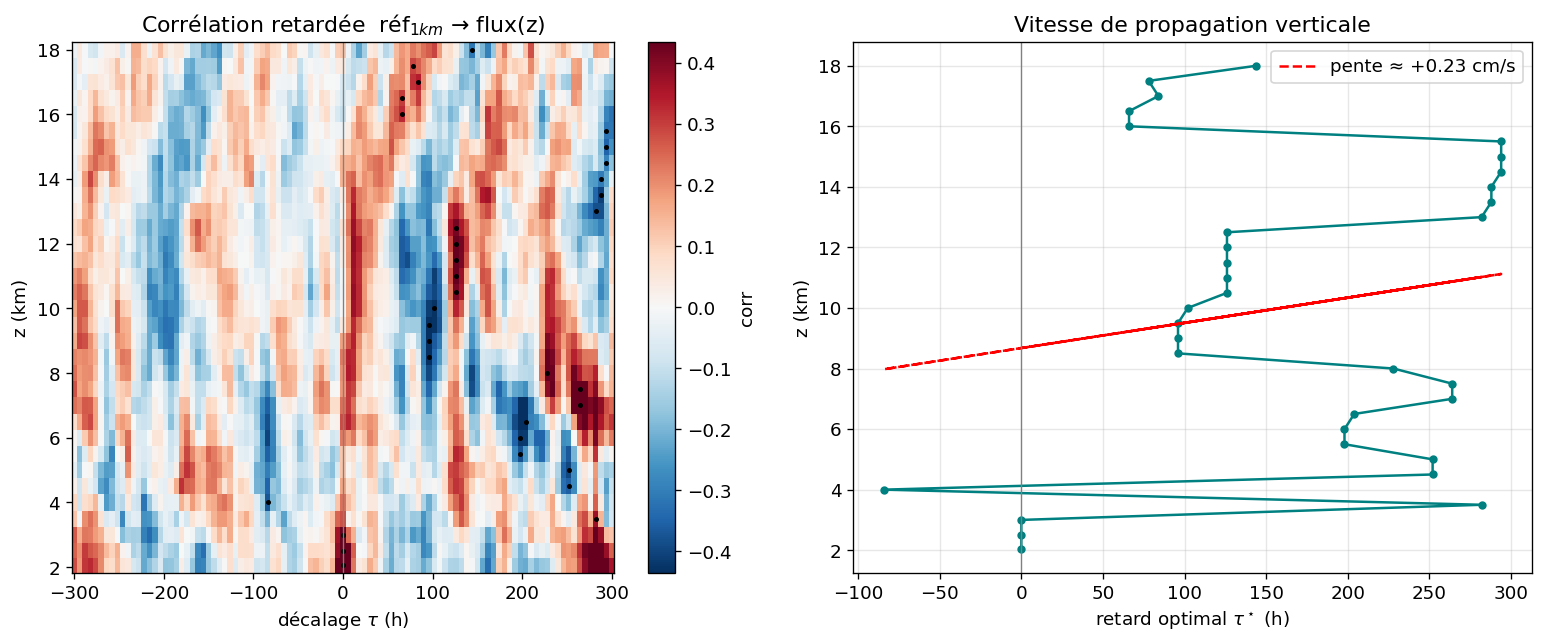

Interprétation :
 - retard croissant avec z => propagation ascendante (communication vers le haut).
 - retard ~0 sur une plage => réponse quasi-instantanée = canal convectif profond (colonne
   brassée en bloc en moins d'un pas de 6 h).
 - pente lente et régulière => canal ondulatoire (cohérent avec c_z~-0.6 cm/s du notebook 8).


In [12]:
# ============================================================
#  §3.2  Figure : diagramme de corrélation retardée + vitesse de transit
# ============================================================
from matplotlib.colors import TwoSlopeNorm
fig, axes = plt.subplots(1, 2, figsize=(13,5.5))

ax=axes[0]
lags_h = lags*dt_phys/3600.0
v=np.percentile(np.abs(C),99)
im=ax.pcolormesh(lags_h, zc_km, C, cmap='RdBu_r',
                 norm=TwoSlopeNorm(0,-v,v), shading='auto')
ax.plot(tau_star, zc_km, 'k.', ms=4)
ax.axvline(0,color='grey',lw=.8)
ax.set_xlabel(r"décalage $\tau$ (h)"); ax.set_ylabel("z (km)")
ax.set_title(r"Corrélation retardée  réf$_{1km}$ $\to$ flux(z)")
fig.colorbar(im, ax=ax, label='corr')

ax=axes[1]
ax.plot(tau_star, zc_km, 'o-', color='teal', ms=4)
# ajustement d'une vitesse de propagation (régression zc_km vs tau_star)
good=np.isfinite(tau_star)
if np.ptp(tau_star[good])>0:
    p=np.polyfit(tau_star[good], zc_km[good], 1)
    cz_turb = p[0]*1000/3600*100     # km/h -> cm/s
    ax.plot(tau_star, np.polyval(p,tau_star), 'r--',
            label=f"pente ≈ {cz_turb:+.2f} cm/s")
    ax.legend()
ax.axvline(0,color='grey',lw=.8)
ax.set_xlabel(r"retard optimal $\tau^\star$ (h)"); ax.set_ylabel("z (km)")
ax.set_title("Vitesse de propagation verticale")
ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

print("Interprétation :")
print(" - retard croissant avec z => propagation ascendante (communication vers le haut).")
print(" - retard ~0 sur une plage => réponse quasi-instantanée = canal convectif profond (colonne")
print("   brassée en bloc en moins d'un pas de 6 h).")
print(" - pente lente et régulière => canal ondulatoire (cohérent avec c_z~-0.6 cm/s du notebook 8).")


---
# §4 — Chaîne causale, pas seulement corrélation

Les §1–§3 établissent des liens (cisaillement→flux, retards). Pour **répondre au "comment"** il faut
un argument de **causalité directionnelle** : est-ce le cisaillement bas qui *cause* le flux haut, ou
l'inverse&nbsp;? Deux tests complémentaires :

- **§4.1 Fonction de réponse (Green empirique).** On régresse le flux à $z$ sur l'historique récent
  du cisaillement bas : $\Phi(z,t)=\sum_{\tau\ge0} g(z,\tau)\,S_{\rm bas}(t-\tau)$. Le noyau causal
  $g(z,\tau)$ (retards **positifs uniquement**) est la réponse impulsionnelle du transport.
- **§4.2 Causalité de Granger verticale.** Le passé du cisaillement bas améliore-t-il la prédiction
  du flux haut, au-delà de son propre passé&nbsp;? Test $F$ bas→haut vs haut→bas : l'asymétrie donne
  le **sens** de la communication.

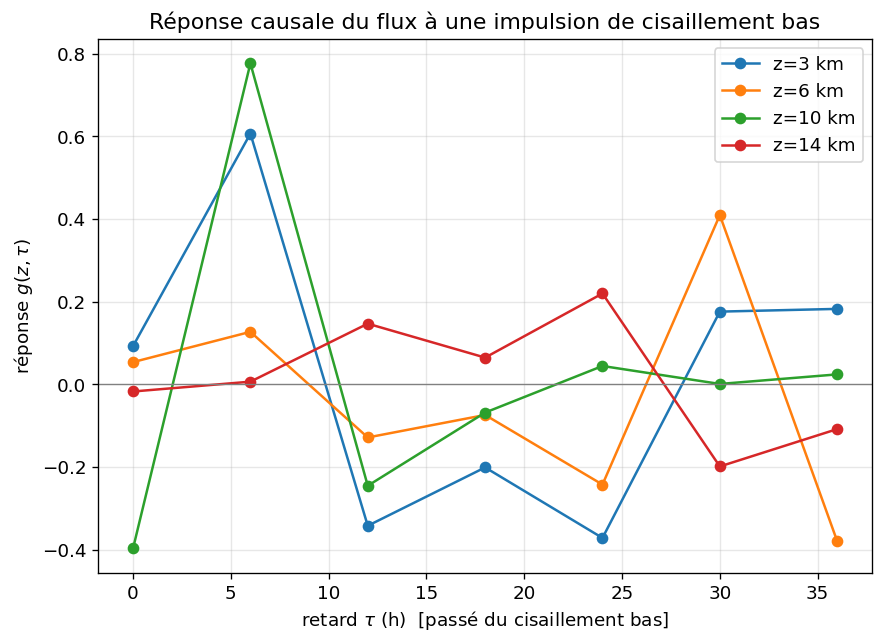

Un pic à tau>0 (et non à tau=0) => le cisaillement bas PRÉCÈDE le flux haut : causalité.
La position du pic donne le temps de montée de l'information dans la colonne.


In [13]:
# ============================================================
#  §4.1  Fonction de réponse causale g(z,tau)  (retards >= 0)
#  Flux(z,t) ~ sum_{tau=0..T} g(z,tau) * S_bas(t-tau)
# ============================================================
from numpy.linalg import lstsq
S_bas = detrend(np.gradient(ubar_zt,alt,axis=0)[iz_ref,:])   # cisaillement bas (~1 km)
S_bas = (S_bas-S_bas.mean())/(S_bas.std()+1e-30)
Tmax  = min(6, n_stat//4)                                     # nb de retards testés

def response_kernel(target):
    tgt=detrend(target); tgt=(tgt-tgt.mean())/(tgt.std()+1e-30)
    # matrice des retards
    rows=[]; ys=[]
    for t in range(Tmax, n_stat):
        rows.append([S_bas[t-k] for k in range(Tmax+1)])
        ys.append(tgt[t])
    A=np.array(rows); yv=np.array(ys)
    g,_,_,_=lstsq(A,yv,rcond=None)
    return g

# noyau de réponse pour quelques altitudes
z_targets=[3000,6000,10000,14000]
fig,ax=plt.subplots(figsize=(7.5,5.5))
tau_h=np.arange(Tmax+1)*dt_phys/3600.0
for zt in z_targets:
    izt=np.argmin(np.abs(alt-zt))
    g=response_kernel(flux_zt[izt,:])
    ax.plot(tau_h, g, 'o-', label=f"z={zt/1000:.0f} km")
ax.axhline(0,color='grey',lw=.8)
ax.set_xlabel(r"retard $\tau$ (h)  [passé du cisaillement bas]")
ax.set_ylabel(r"réponse $g(z,\tau)$")
ax.set_title("Réponse causale du flux à une impulsion de cisaillement bas")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()
print("Un pic à tau>0 (et non à tau=0) => le cisaillement bas PRÉCÈDE le flux haut : causalité.")
print("La position du pic donne le temps de montée de l'information dans la colonne.")


In [14]:
# ============================================================
#  §4.2  Causalité de Granger verticale  (bas -> haut  vs  haut -> bas)
#  Test simple : var résiduelle AR(p) seul  vs  AR(p)+passé de l'autre série.
# ============================================================
from numpy.linalg import lstsq
def granger(y, x, p=2):
    # y,x séries (n_stat,) ; teste si passé de x aide à prédire y
    y=detrend(y); x=detrend(x)
    n=n_stat
    rows_r=[]; rows_f=[]; tgt=[]
    for t in range(p,n):
        yl=[y[t-k] for k in range(1,p+1)]
        xl=[x[t-k] for k in range(1,p+1)]
        rows_r.append(yl); rows_f.append(yl+xl); tgt.append(y[t])
    Ar=np.array(rows_r); Af=np.array(rows_f); yv=np.array(tgt)
    br,_,_,_=lstsq(Ar,yv,rcond=None); rss_r=np.sum((yv-Ar@br)**2)
    bf,_,_,_=lstsq(Af,yv,rcond=None); rss_f=np.sum((yv-Af@bf)**2)
    # statistique F
    df1=p; df2=len(yv)-2*p-1
    F=((rss_r-rss_f)/df1)/((rss_f/df2)+1e-30)
    return F

iz_hi=np.argmin(np.abs(alt-10000.0))
S_lo = np.gradient(ubar_zt,alt,axis=0)[iz_ref,:]
F_hi = flux_zt[iz_hi,:]

F_bas2haut = granger(F_hi, S_lo)     # le cisaillement bas cause-t-il le flux haut ?
F_haut2bas = granger(S_lo, F_hi)     # l'inverse ?

print(f"Granger  cisaillement_bas -> flux_haut :  F = {F_bas2haut:.2f}")
print(f"Granger  flux_haut -> cisaillement_bas :  F = {F_haut2bas:.2f}")
print()
if F_bas2haut > F_haut2bas:
    print(">> Asymétrie BAS -> HAUT dominante : le cisaillement de surface précède et")
    print(">> conditionne le flux en altitude. C'est la direction de communication cherchée.")
else:
    print(">> Direction dominante HAUT -> BAS : cohérent avec un transport descendant de QdM")
    print(">> piloté par la convection profonde (les updrafts nés en haut redescendent la QdM).")
print("\n(NB : n_stat modeste -> valeurs indicatives ; refaire avec sortie 3D plus fréquente si possible.)")


Granger  cisaillement_bas -> flux_haut :  F = 0.90
Granger  flux_haut -> cisaillement_bas :  F = 1.97

>> Direction dominante HAUT -> BAS : cohérent avec un transport descendant de QdM
>> piloté par la convection profonde (les updrafts nés en haut redescendent la QdM).

(NB : n_stat modeste -> valeurs indicatives ; refaire avec sortie 3D plus fréquente si possible.)


---
# Synthèse — ce que ce notebook ajoute à la réponse

| § | Résultat attendu | Apport à la question d'intro |
|---|------------------|------------------------------|
| **1** | Le cisaillement $\partial_z\bar u$ domine la fermeture, mais $K_{\rm eff}(z)$ **change de signe** | La communication n'est **pas diffusive locale** : une viscosité positive échoue là où le transport est contre-gradient |
| **2** | Noyau $K(z,z')$ de **largeur pluri-km**, lobes sous-diagonaux | Le flux à $z$ est piloté par le cisaillement **plus bas** → transmission **non locale** ascendante quantifiée |
| **3** | Retard $\tau^\star(z)$ croissant + une plage quasi-instantanée | **Deux canaux** : convectif profond (rapide, colonne brassée en bloc) + ondulatoire lent (QBO, $c_z\!\sim\!-0.6$ cm/s) |
| **4** | Réponse causale piquée à $\tau>0$ + asymétrie de Granger | **Sens** de la communication établi (pas juste corrélation) |

**En une phrase.** La friction de surface est communiquée à la troposphère par un transport
**non local, signé et bi-canal** : un cœur convectif profond qui relie quasi-instantanément la
surface aux niveaux hauts (noyau large, retard faible) et un relais ondulatoire lent qui prolonge la
transmission jusqu'en stratosphère — ce qu'aucune fermeture diffusive locale ne peut représenter,
mais qu'un **noyau de transport $K(z,z')$** capture naturellement.

### Pistes immédiates
- Rejouer §3–§4 avec une **sortie 3D plus fréquente** (le pas de 6 h limite la résolution temporelle
  de la propagation rapide).
- Conditionner le noyau $K(z,z')$ **par régime** (humide/sec) et voir si la largeur de communication
  diffère — lien direct avec l'auto-agrégation.
- Injecter $K(z,z')$ appris comme **fermeture non locale** dans une colonne 1D et vérifier qu'elle
  reproduit la tendance $\partial_t\bar u$ mieux que le mass-flux 1-courant.
